In [1]:
# Step 1: Import Libraries
# KMeans: Used to perform K-Means clustering.
# numpy (np): Handles arrays for pixel manipulation.
# PIL.Image: Used for opening and manipulating image files.
# matplotlib.pyplot: For displaying the images.
# mpimg: Loads the images for display.
# import os: Allows interaction with the operating system for file handling, checking file existence, and working
# with file paths. It's useful in file management tasks.
# %matplotlib inline: Ensures that plots generated with matplotlib are displayed inline within a Jupyter notebook, 
# making the output directly visible below the code cells.
# This ensures that when you run the plotting commands like plt.show(), the images will display inside the notebook
# below the cell where the code is executed.
from sklearn.cluster import KMeans  
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt  
import matplotlib.image as mpimg  
import os
%matplotlib inline

In [2]:
# Step 2: Get the Image and its Corresponding RGB Values
# Open the image from the specified path
# Image.open(): Opens the image file.
img = Image.open(r'D:\4th semester\Defender.jpeg')
# Convert the image to a numpy array for easier manipulation
# np.asarray(): Converts the image into a numpy array, where each pixel is represented as an RGB triplet (Red, Green, Blue).
img_np=np.asarray(img) 
# Display the first 2 rows of the image array
img_np[0:2]

array([[[ 90,  84,  86],
        [ 90,  84,  86],
        [ 90,  84,  86],
        ...,
        [124, 120, 121],
        [124, 120, 121],
        [124, 120, 121]],

       [[ 90,  84,  86],
        [ 90,  84,  86],
        [ 90,  84,  86],
        ...,
        [124, 120, 121],
        [124, 120, 121],
        [124, 120, 121]]], dtype=uint8)

In [3]:
# Step 3: Get the Image Dimensions
# Get the dimensions of the image
img_np.shape
# img_np.shape: Provides the dimensions of the image, which returns a tuple of the form (height, width, channels).
# channels should be 3 (for RGB).

(1303, 2499, 3)

In [4]:
# Step 4: Reshape the Data
# Reshape the image data into a two-dimensional array, where each row represents a pixel and each column represents
# a color channel (RGB)
pixels=img_np.reshape(img_np.shape[0]*img_np.shape[1],img_np.shape[2])  
pixels.shape
# Reshape the image data from 3D (height, width, channels) to 2D (number of pixels, 3). This is necessary for applying K-means clustering.
# pixels.shape will output (total_pixels, 3), where 3 represents the RGB channels.

(3256197, 3)

In [5]:
# Step 5: Define the K-means Model
# Define the K-means clustering model with 16 clusters
model=KMeans(n_clusters=16)  
model.fit(pixels)
# n_clusters=16: Specifies that we want to reduce the image to 16 colors (clusters).
# fit(pixels): Fits the K-means model to the image's pixel data.

KMeans(n_clusters=16)

In [6]:
# Step 6: Define the Cluster Centers
# Get the pixel cluster assignments (labels)
pixel_centroids = model.labels_  
# Get the RGB values of the cluster centers (the 16 colors)
cluster_centers=model.cluster_centers_  
# Display the pixel centroids (labels)
pixel_centroids
# model.labels_: Returns an array where each element represents the cluster assignment (centroid) for each pixel.
# model.cluster_centers_: Returns the RGB values for the 16 cluster centers (colors).

array([ 4,  4,  4, ..., 10, 10, 10])

In [7]:
cluster_centers

array([[199.71446891, 196.94075269, 202.08730765],
       [ 27.44770242,  26.68264457,  29.42453384],
       [125.12628351, 119.95271416, 126.47465773],
       [ 65.91505336,  59.22390225,  62.67059852],
       [ 84.73841364,  81.02154332,  86.91500652],
       [158.54356581, 152.24377151, 155.00718213],
       [244.82705638, 243.56559655, 247.53854017],
       [104.83833295, 101.33341502, 108.75010722],
       [129.67103808, 177.41740401, 209.07994944],
       [ 45.86907283,  43.22980033,  46.06738803],
       [172.22935656, 162.83342974, 166.79459479],
       [ 14.45245155,  14.11795194,  16.31740281],
       [146.65841207, 140.72713895, 145.61158393],
       [185.98224297, 181.26470096, 185.72779702],
       [ 97.0397657 , 131.07107062, 168.48330622],
       [215.4248801 , 213.02034507, 218.3177693 ]])

In [8]:
# Step 7: Cluster Assignment
# Create an empty array to store the compressed image data
final=np.zeros((pixel_centroids.shape[0],3))
# Assign each pixel the color of its cluster center
for cluster_no in range(16):  
    final[pixel_centroids==cluster_no]=cluster_centers[cluster_no]
# Display the first 5 rows of the compressed image data
final[0:5]

array([[84.73841364, 81.02154332, 86.91500652],
       [84.73841364, 81.02154332, 86.91500652],
       [84.73841364, 81.02154332, 86.91500652],
       [84.73841364, 81.02154332, 86.91500652],
       [84.73841364, 81.02154332, 86.91500652]])

In [9]:
# Step 8: Reshape to Original Dimensions
# Reshape the compressed image data back to its original dimensions (height, width, 4)
comp_image=final.reshape(img_np.shape[0],img_np.shape[1],3) 
# Display the shape of the compressed image
comp_image.shape
# Reshape the 2D array back into the original 3D shape (height, width, 4) to reconstruct the compressed image.

(1303, 2499, 3)

In [10]:
# Step 9: Convert the Pixel Values to Image
# Convert the numpy array of compressed image data back to an image
comp_image=Image.fromarray(np.uint8(comp_image))
# Save the compressed image
comp_image.save('Defender_compressed.jpeg') 
# Load the original and compressed images for comparison
img_1 = mpimg.imread(r'D:\4th semester\Defender.jpeg')
img_2 = mpimg.imread('Defender_compressed.jpeg')

# Image.fromarray(): Converts the numpy array back into an image.
# np.uint8(): Converts the data into 8-bit unsigned integers (values between 0 and 255, which is the standard for image pixel data).
# comp_image.save(): Saves the compressed image as tiger_compressed.png.

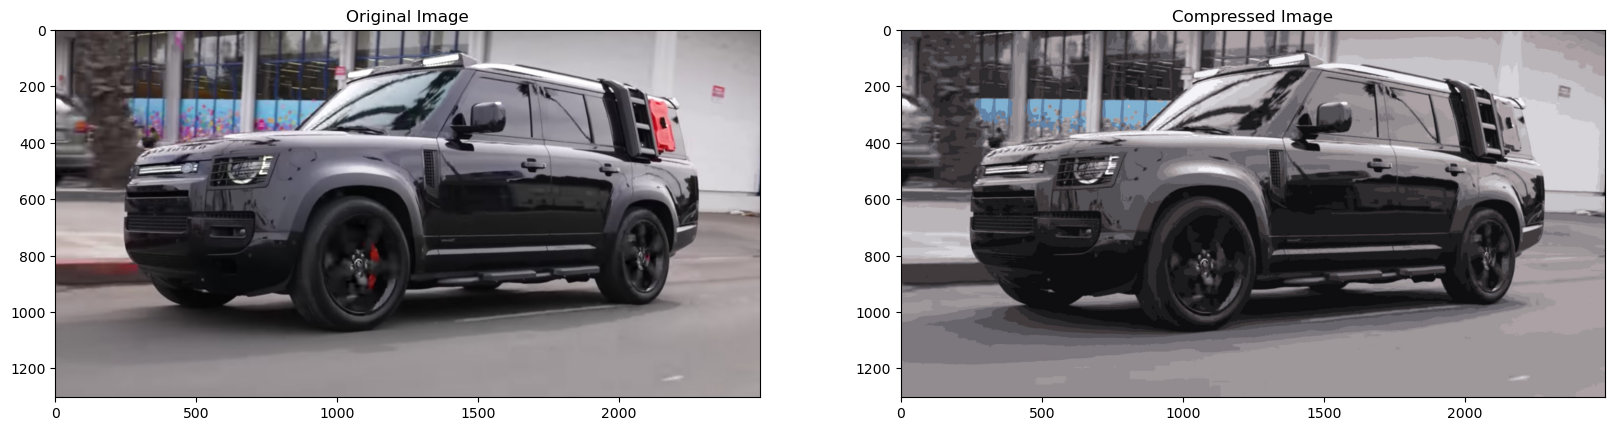

In [11]:
# Create a side-by-side comparison of the original image and the compressed image
fig,(ax1,ax2) = plt.subplots(1,2, figsize=(20,20)) 
# Show the original image
ax1.imshow(img_1)
ax1.set_title('Original Image')
# Show the compressed image
ax2.imshow(img_2)
ax2.set_title('Compressed Image')
plt.show()